## Importy

In [1]:
import os
import re
from scripts.cvrp_ilp import solve_cvrp_ilp as solve_cvrp_ilp_basic
from scripts.cvrp_ilp_opt import solve_cvrp_ilp as solve_cvrp_ilp_opt
from scripts.cvrp_ilp_warm import solve_cvrp_ilp as solve_cvrp_ilp_warm
from scripts.cvrp_genetic import solve_cvrp_ga
from scripts.cvrp_hybrid import solve_cvrp_hybrid
from scripts.cvrp_hybrid_candidate import solve_cvrp_hybrid_candidate as solve_cvrp_hybrid_candidate

from scripts.plot_utils import plot_cbc_log, plot_ga_log, plot_hybrid_log

## Funkcje Pomocnicze

In [2]:
def get_optimal_cost(vrp_filepath):
    sol_filepath = vrp_filepath.replace('.vrp', '.sol')
    if os.path.exists(sol_filepath):
        with open(sol_filepath, 'r') as f:
            for line in f:
                if line.startswith('Cost'):
                    match = re.search(r'Cost\s+(\d+)', line)
                    if match:
                        return float(match.group(1))
    return None


def run_experiments(instances, solver_function, **kwargs):
    for inst in instances:
        if os.path.exists(inst):
            try:
                opt_cost = get_optimal_cost(inst)
                solver_function(inst, **kwargs)

                if solver_function.__name__ == 'solve_cvrp_ga':
                    plot_ga_log(optimum_cost=opt_cost)
                    
                elif solver_function.__name__ in ['solve_cvrp_hybrid', 'solve_cvrp_hybrid_candidate']:
                    plot_hybrid_log(optimum_cost=opt_cost)

                else:
                    plot_cbc_log(optimum_cost=opt_cost)

            except Exception as e:
                print(f"Błąd podczas analizy {inst}: {e}")
        else:
            print(f"Plik {inst} nie istnieje!")

## Instancje

In [3]:
instances = [
    os.path.join('data', 'E', 'E-n51-k5.vrp')
]

## Algorytm ILP Klasyczny

Wczytano 50 klientów, depot: 1, pojemność: 160, maks. ciężarówek: 5
Uruchamianie solvera
Czas wykonania: 116.56 s
Status: Optimal
Minimal tour: 1330.0
Routes: [[1, 9, 35, 31, 14, 18, 37, 36, 38, 45, 43, 1], [1, 17, 3, 4, 21, 15, 8, 24, 7, 1], [1, 25, 6, 12, 39, 34, 46, 16, 2, 23, 29, 32, 1], [1, 28, 33, 19, 5, 48, 13, 30, 22, 20, 1], [1, 41, 49, 42, 27, 26, 51, 10, 50, 11, 44, 40, 47, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


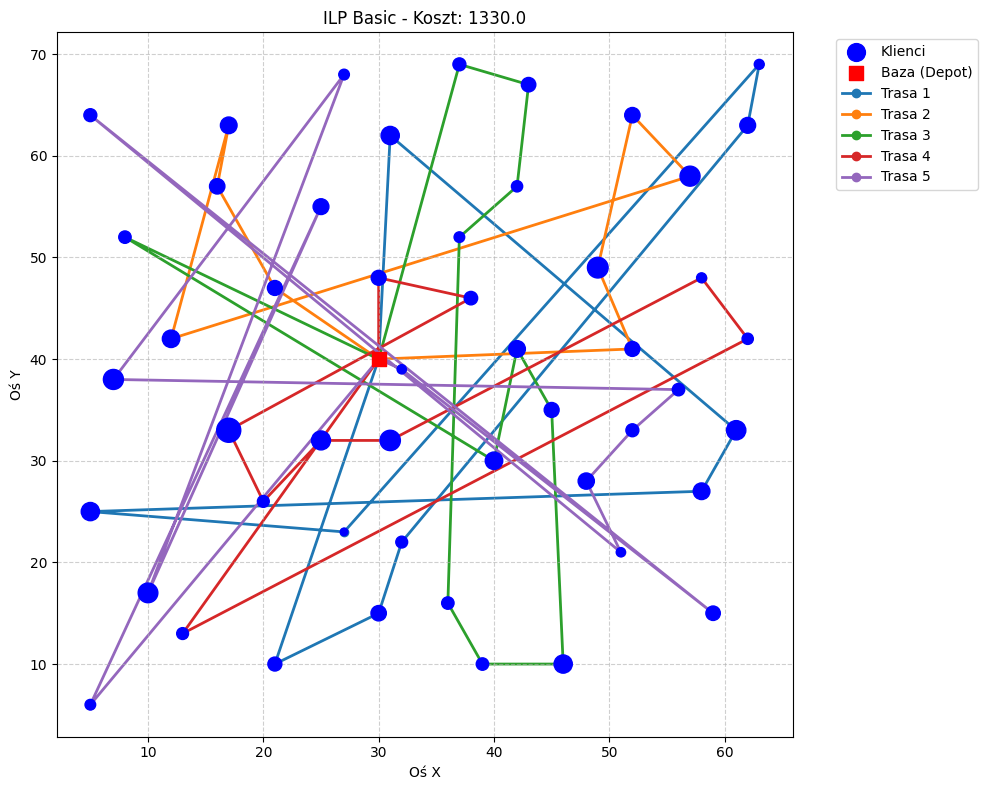

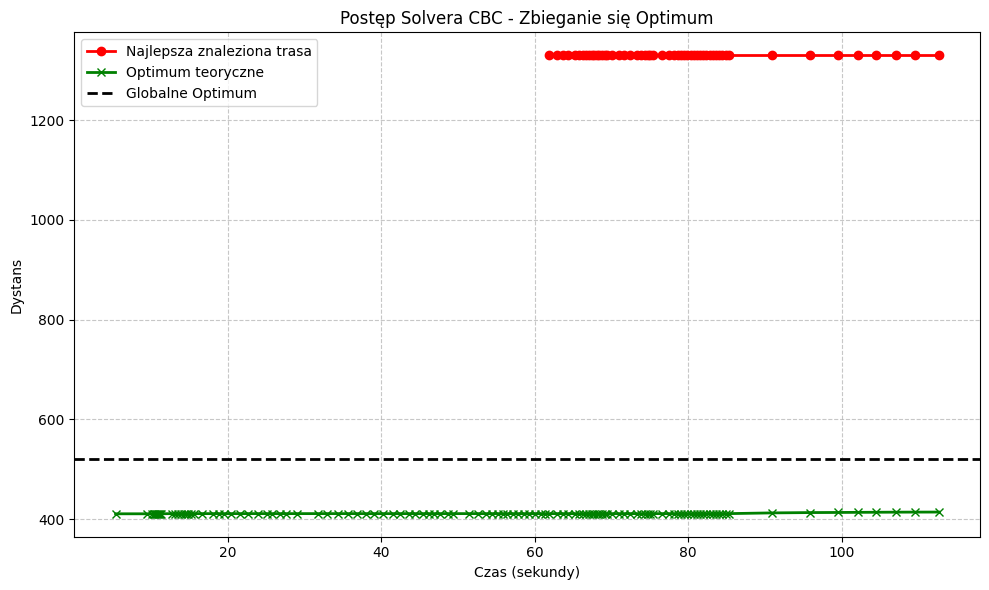

In [4]:
run_experiments(instances, solve_cvrp_ilp_basic, time_limit=120)

## Algorytm ILP z Optymalizacjami

Wczytano 50 klientów, depot: 1, pojemność: 160, maks. ciężarówek: 5
Uruchamianie solvera
Czas wykonania: 120.10 s
Status: Not Solved
Zapisano statystyki eksperymentu do results\experiments.csv


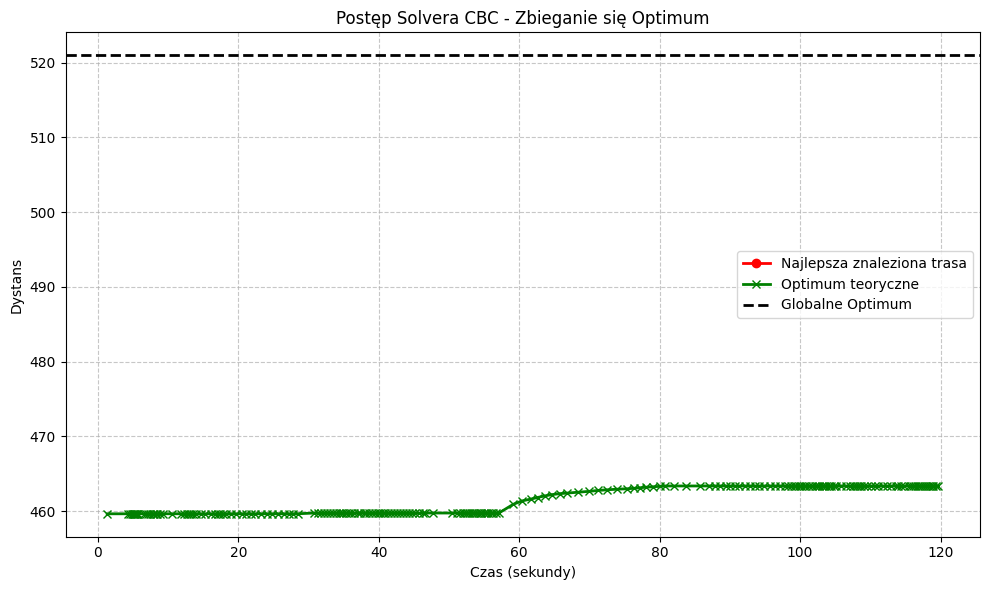

In [5]:
run_experiments(instances, solve_cvrp_ilp_opt, time_limit=120)

## Algorytm ILP z Optymalizacjami i 'Warm Start NN'

Wczytano 50 klientów, depot: 1, pojemność: 160, maks. ciężarówek: 5
Uruchamianie solvera
Czas wykonania: 120.16 s
Status: Optimal
Minimal tour: 728.0
Routes: [[1, 3, 23, 8, 24, 25, 44, 35, 31, 40, 1], [1, 7, 49, 9, 27, 32, 29, 4, 21, 36, 37, 1], [1, 19, 15, 26, 14, 41, 46, 34, 1], [1, 28, 2, 33, 12, 39, 6, 50, 10, 51, 17, 30, 22, 1], [1, 47, 13, 48, 5, 18, 38, 16, 45, 43, 20, 42, 11, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


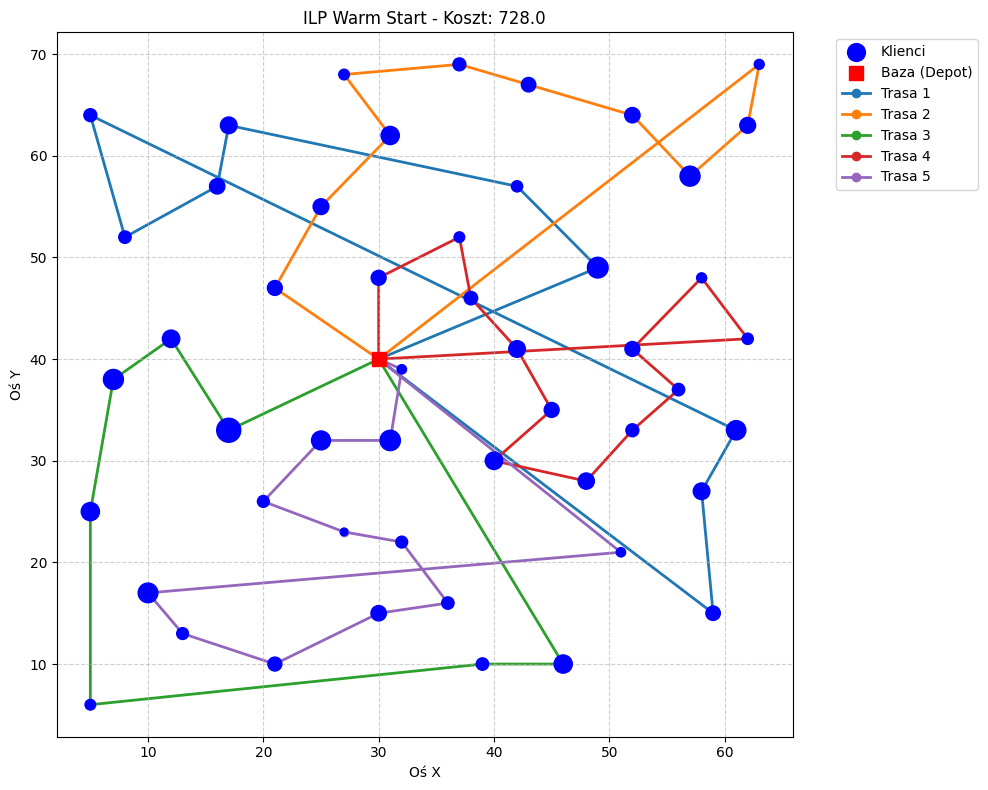

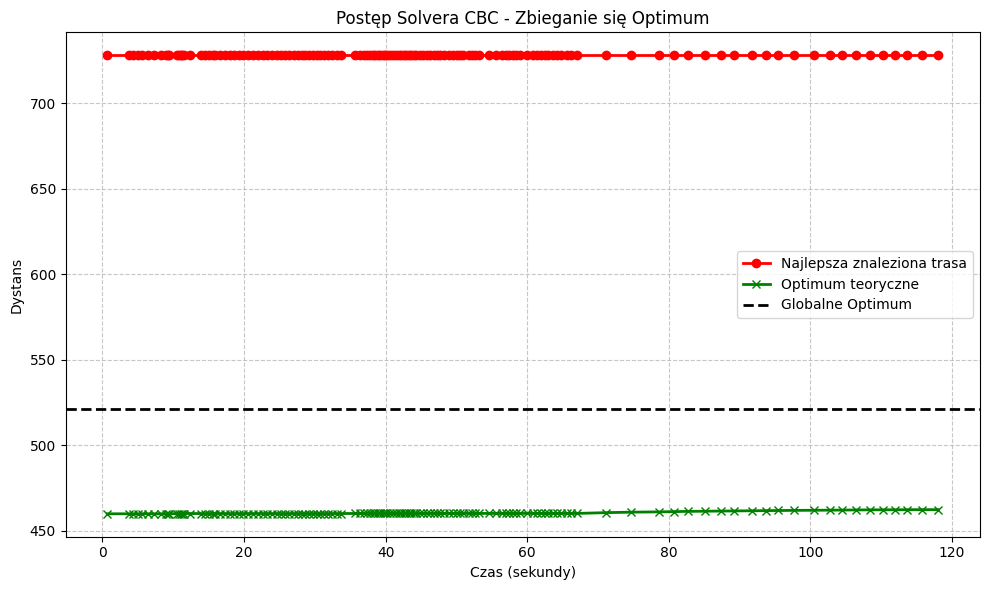

In [6]:
run_experiments(instances, solve_cvrp_ilp_warm, time_limit=120)

## Algorytm Genetyczny

Wczytano 50 klientów, depot: 1, pojemność: 160, maks. ciężarówek: 5
Parametry GA: Populacja=1000, Pokolenia=10000, Limit czasu=120s
Uruchamianie algorytmu genetycznego
Przerwano: Osiągnięto limit czasu 120s (Pokolenie: 2207)
Czas wykonania: 120.06 s
Minimal tour (Feasible): 556
Routes: [[1, 47, 6, 39, 12, 17, 21, 36, 37, 4, 23, 2, 1], [1, 10, 50, 11, 40, 31, 35, 51, 22, 30, 3, 33, 1], [1, 13, 38, 16, 34, 46, 45, 18, 5, 19, 1], [1, 28, 49, 9, 29, 32, 27, 8, 24, 44, 25, 7, 1], [1, 48, 43, 41, 20, 42, 14, 26, 15, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


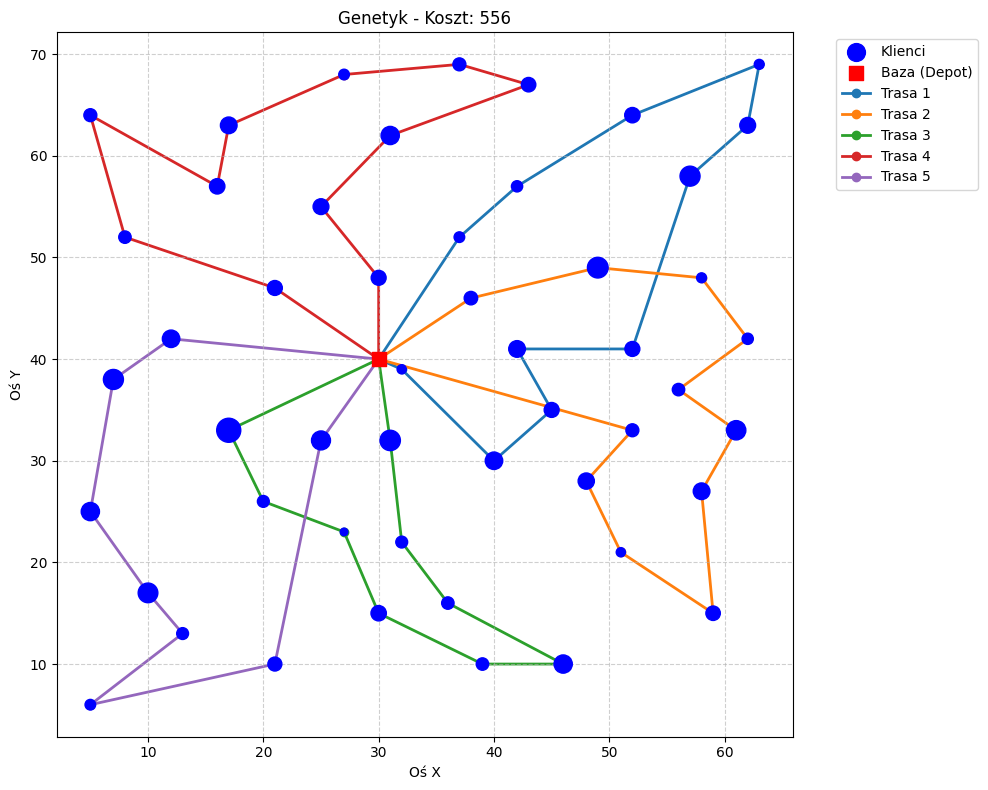

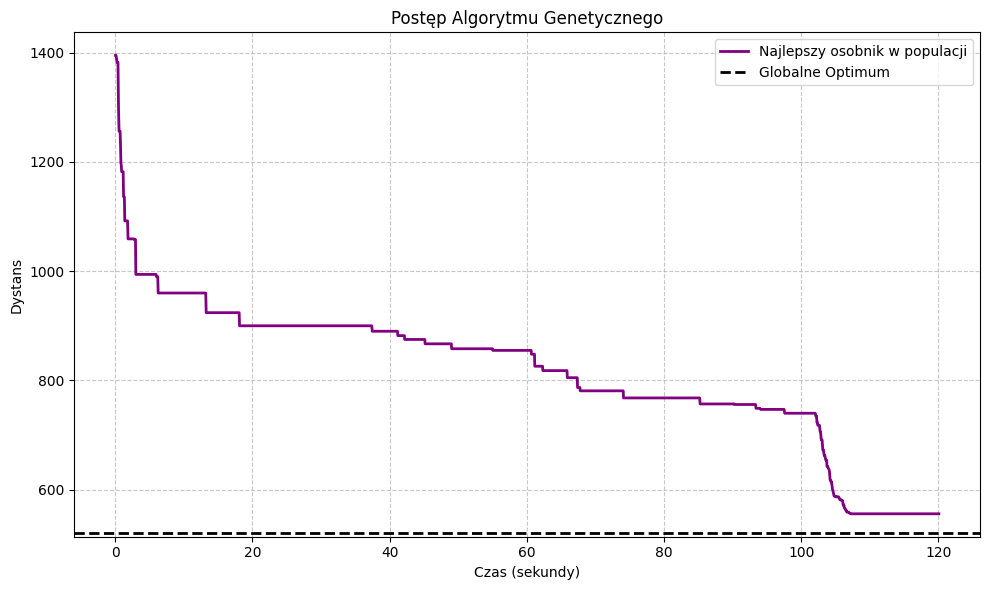

In [7]:
run_experiments(instances, solve_cvrp_ga, time_limit=120, population_size=1000, generations=10000, seed=42)

## Algorytm Hybrydowy

Krok 1: Inicjalizacja Algorytmem Genetycznym
Wczytano 50 klientów, depot: 1, pojemność: 160, maks. ciężarówek: 5
Parametry GA: Populacja=1000, Pokolenia=5000, Limit czasu=20s
Uruchamianie algorytmu genetycznego
Przerwano: Osiągnięto limit czasu 20s (Pokolenie: 319)
Czas wykonania: 20.05 s
Minimal tour (Feasible): 900
Routes: [[1, 34, 46, 16, 45, 13, 50, 4, 36, 37, 39, 1], [1, 38, 5, 19, 18, 47, 12, 31, 40, 11, 28, 7, 1], [1, 22, 17, 51, 30, 3, 21, 35, 2, 6, 1], [1, 48, 33, 23, 26, 14, 41, 20, 43, 42, 1], [1, 9, 27, 8, 24, 44, 25, 15, 49, 32, 29, 10, 1]]

Krok 2: Uruchamianie solvera ILP
Czas wykonania: 100.15 s
Status: Optimal
Minimal tour: 870.0
Routes: [[1, 13, 35, 2, 51, 42, 20, 41, 43, 45, 1], [1, 18, 17, 36, 3, 37, 4, 29, 32, 27, 9, 49, 1], [1, 28, 8, 44, 25, 15, 26, 14, 24, 7, 1], [1, 40, 34, 50, 16, 46, 38, 6, 39, 12, 33, 23, 1], [1, 48, 19, 5, 22, 30, 21, 31, 10, 11, 47, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


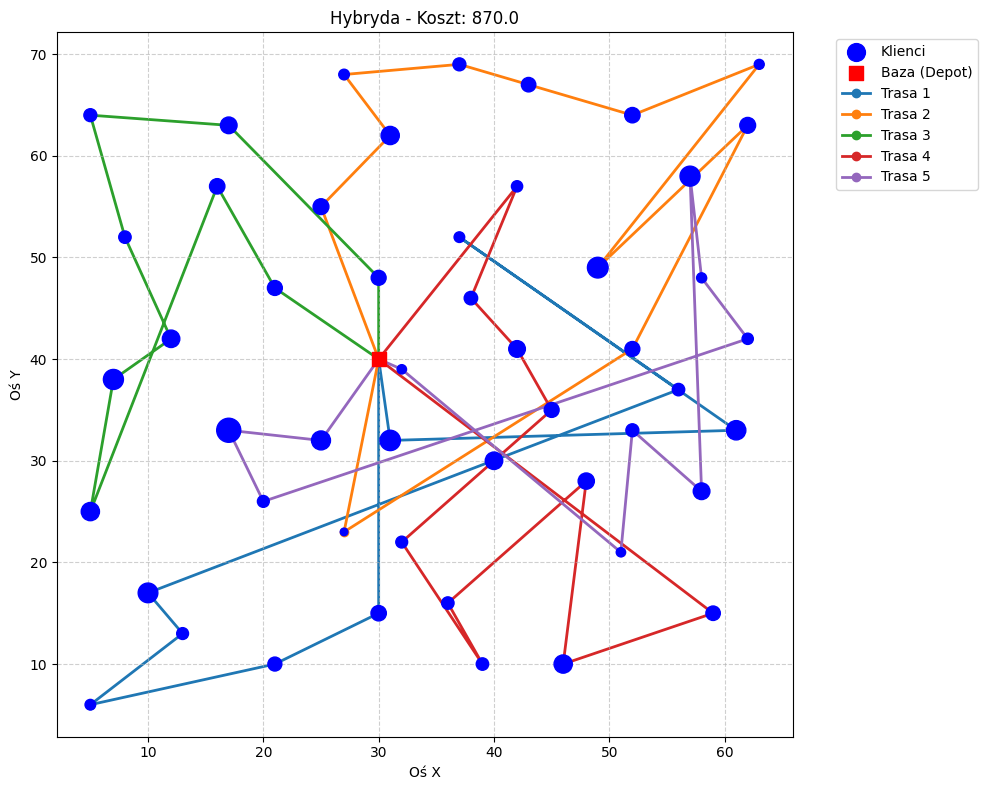

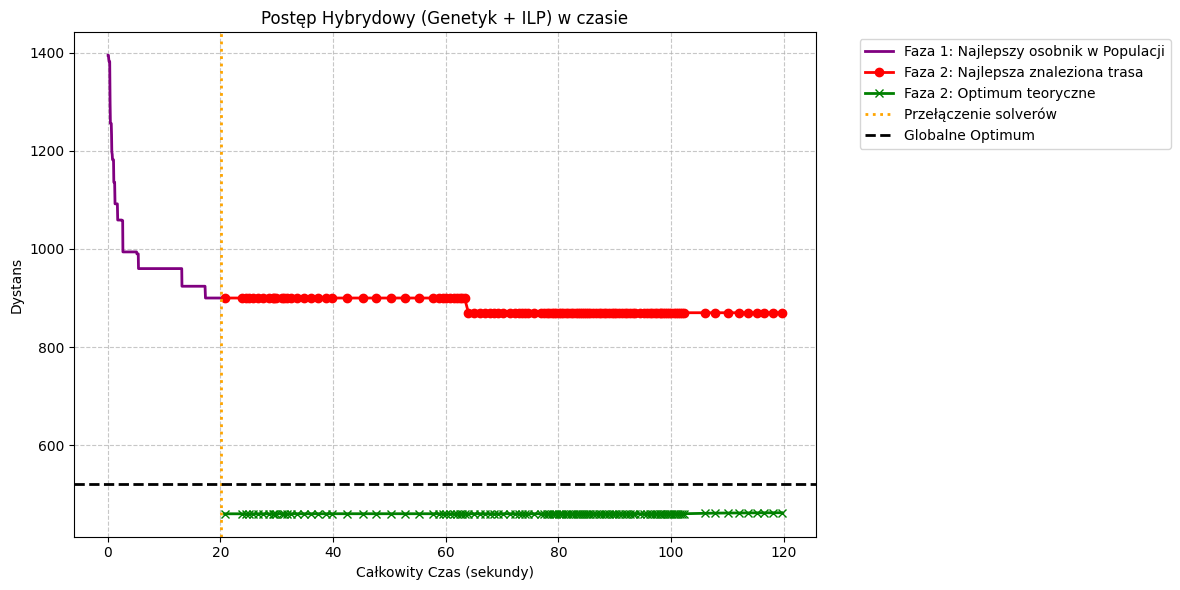

In [8]:
run_experiments(instances, solve_cvrp_hybrid, ga_time_limit=20, ilp_time_limit=100, population_size=1000, generations=5000, seed=42)

## Algorytm Hybrydowy - inne parametry

Krok 1: Inicjalizacja Algorytmem Genetycznym
Wczytano 50 klientów, depot: 1, pojemność: 160, maks. ciężarówek: 5
Parametry GA: Populacja=1000, Pokolenia=5000, Limit czasu=90s
Uruchamianie algorytmu genetycznego
Przerwano: Osiągnięto limit czasu 90s (Pokolenie: 1368)
Czas wykonania: 90.02 s
Minimal tour (Feasible): 781
Routes: [[1, 17, 39, 16, 34, 46, 45, 18, 38, 5, 19, 47, 1], [1, 12, 33, 3, 30, 22, 10, 31, 40, 35, 51, 1], [1, 4, 37, 21, 36, 29, 32, 27, 23, 11, 50, 7, 28, 1], [1, 6, 48, 14, 41, 20, 43, 42, 9, 2, 1], [1, 26, 15, 25, 44, 24, 49, 8, 13, 1]]

Krok 2: Uruchamianie solvera ILP
Czas wykonania: 30.12 s
Status: Optimal
Minimal tour: 781.0
Routes: [[1, 4, 37, 21, 36, 29, 32, 27, 23, 11, 50, 7, 28, 1], [1, 6, 48, 14, 41, 20, 43, 42, 9, 2, 1], [1, 12, 33, 3, 30, 22, 10, 31, 40, 35, 51, 1], [1, 17, 39, 16, 34, 46, 45, 18, 38, 5, 19, 47, 1], [1, 26, 15, 25, 44, 24, 49, 8, 13, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


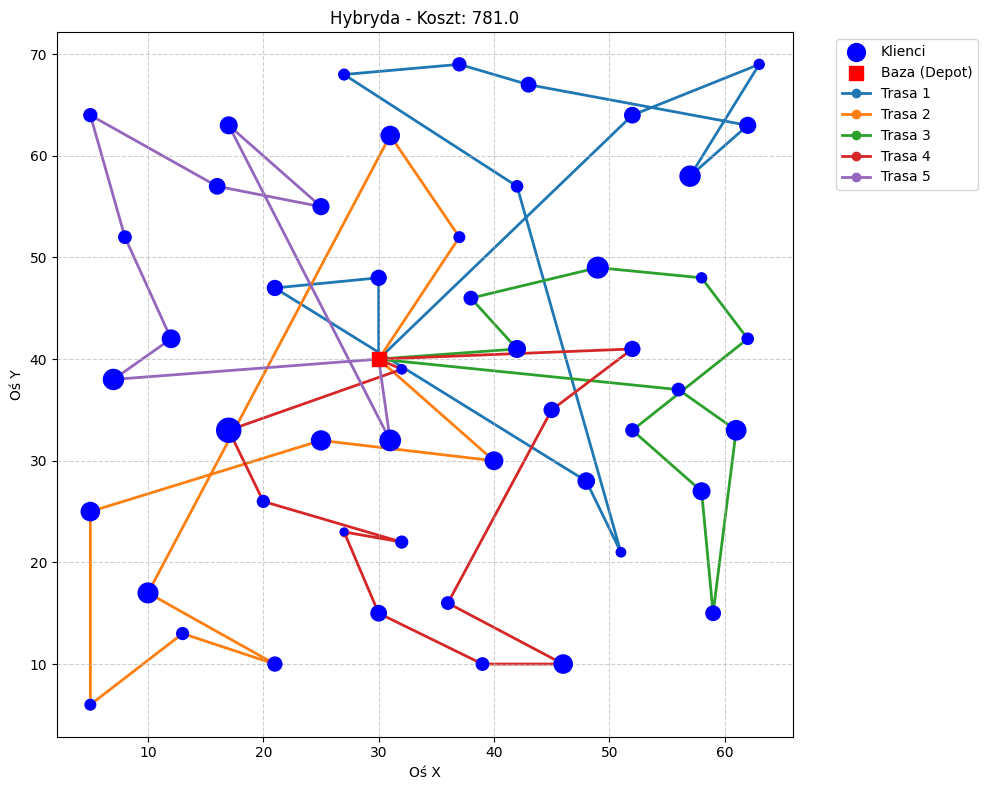

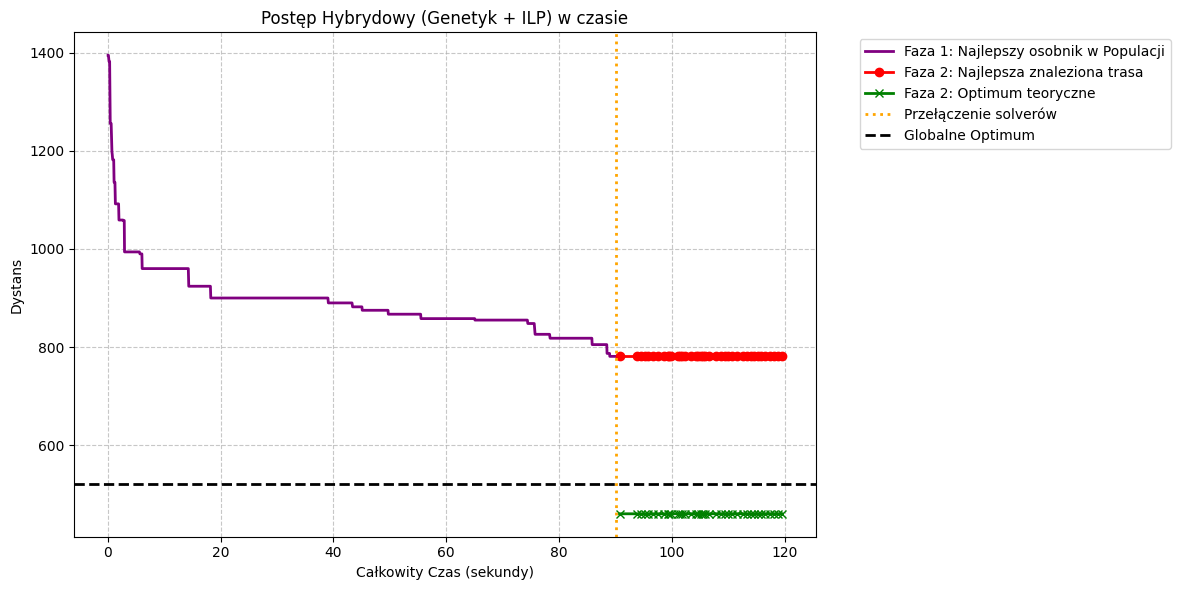

In [9]:
run_experiments(instances, solve_cvrp_hybrid, ga_time_limit=90, ilp_time_limit=30, population_size=1000, generations=5000, seed=42)

## Algorytm Hybrydowy z ograniczeniem krawędzi

Krok 1: Inicjalizacja Algorytmem Genetycznym
Wczytano 50 klientów, depot: 1, pojemność: 160, maks. ciężarówek: 5
Parametry GA: Populacja=1000, Pokolenia=10000, Limit czasu=90s
Uruchamianie algorytmu genetycznego
Przerwano: Osiągnięto limit czasu 90s (Pokolenie: 1438)
Czas wykonania: 90.01 s
Minimal tour (Feasible): 781
Routes: [[1, 17, 39, 16, 34, 46, 45, 18, 38, 5, 19, 47, 1], [1, 12, 33, 3, 30, 22, 10, 31, 40, 35, 51, 1], [1, 4, 37, 21, 36, 29, 32, 27, 23, 11, 50, 7, 28, 1], [1, 6, 48, 14, 41, 20, 43, 42, 9, 2, 1], [1, 26, 15, 25, 44, 24, 49, 8, 13, 1]]

Krok 2: Uruchamianie solvera ILP z filtrowaniem krawędzi
Czas wykonania: 30.10 s
Status: Optimal
Minimal tour: 781.0
Routes: [[1, 4, 37, 21, 36, 29, 32, 27, 23, 11, 50, 7, 28, 1], [1, 6, 48, 14, 41, 20, 43, 42, 9, 2, 1], [1, 12, 33, 3, 30, 22, 10, 31, 40, 35, 51, 1], [1, 17, 39, 16, 34, 46, 45, 18, 38, 5, 19, 47, 1], [1, 26, 15, 25, 44, 24, 49, 8, 13, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


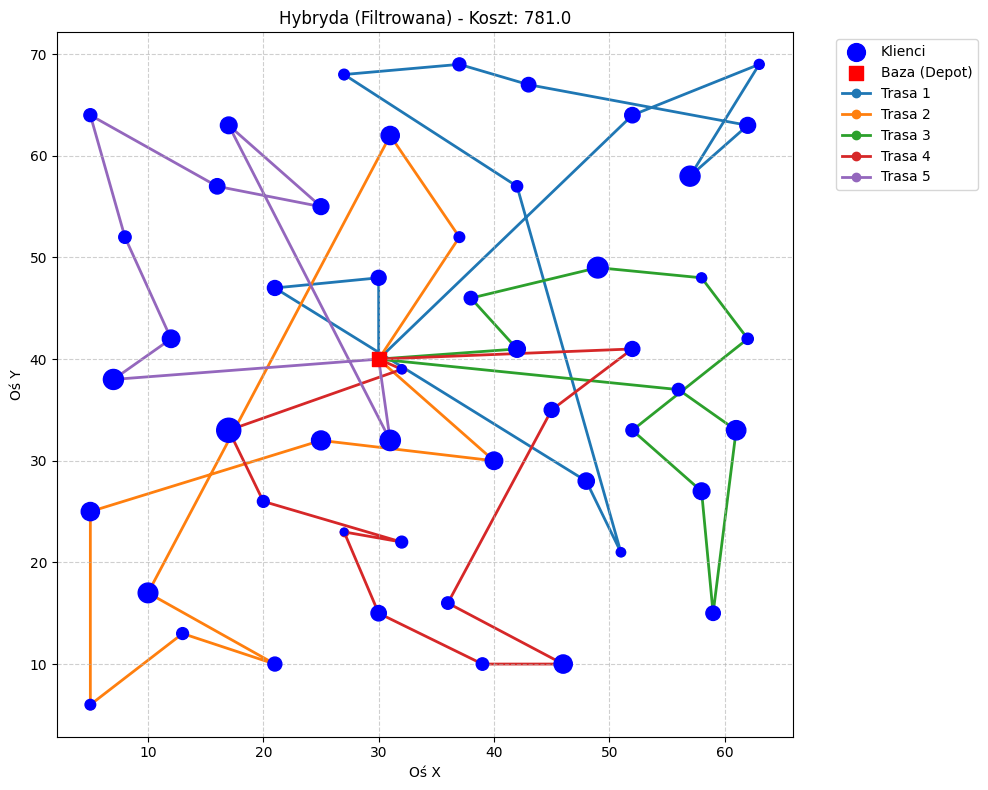

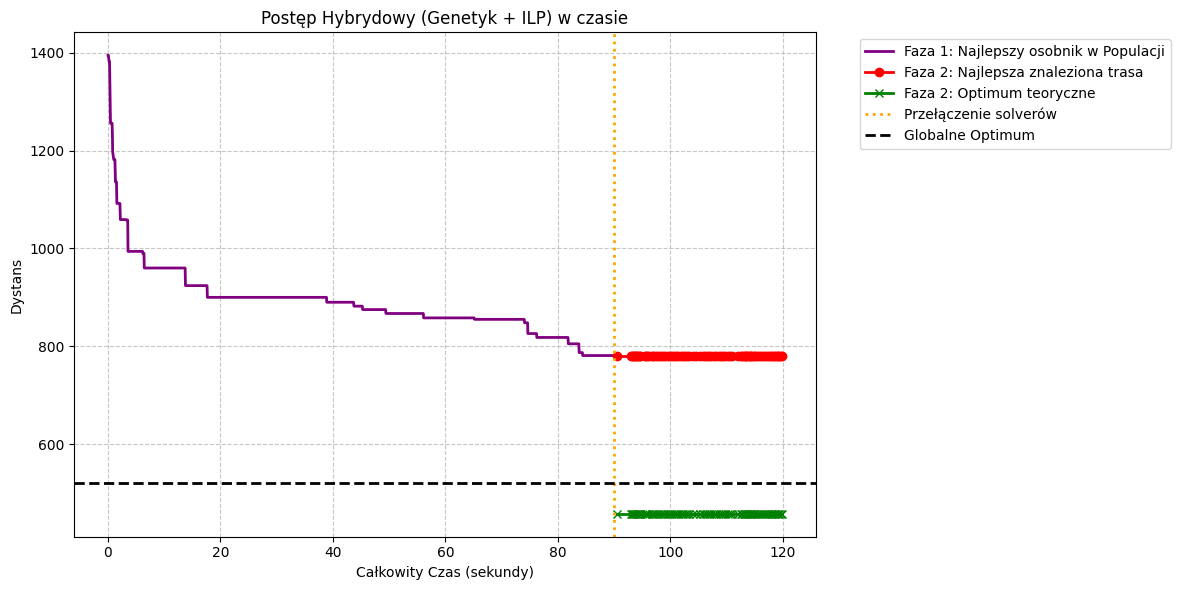

In [10]:
run_experiments(instances, solve_cvrp_hybrid_candidate, ga_time_limit=90, ilp_time_limit=30, population_size=1000, generations=10000, seed=42)